In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# Solver and simulation parameters
# M_vector = [4, 5, 6, 7, 8]
M_vector = [4, 5, 6, 8]
closure_vec = ["Gram", "ExtGram"]#!["Gram", "ExtGram", "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 11
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

In [4]:
# file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [5]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/3084373403.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/3084373403.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_eig_even.legend()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/3084373403.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_eig_odd.legend()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/3084373403.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/3084373403.py:76: UserWarning: FigureCanvasA

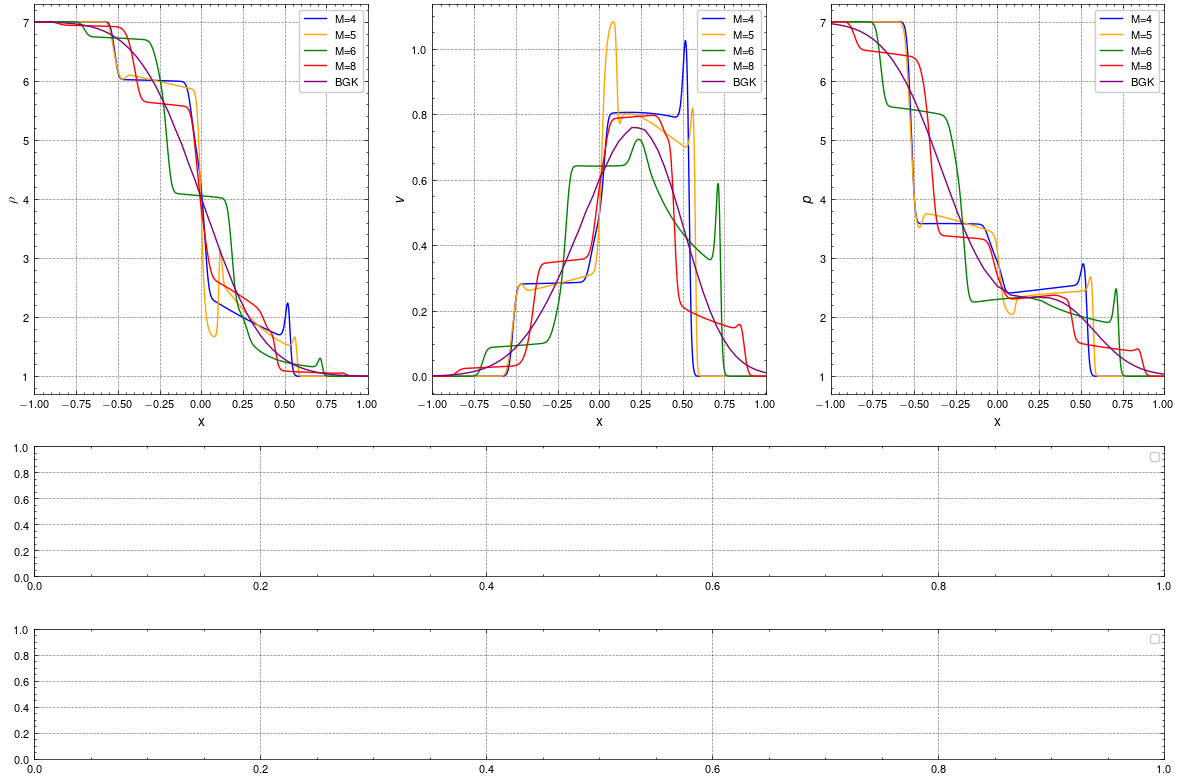

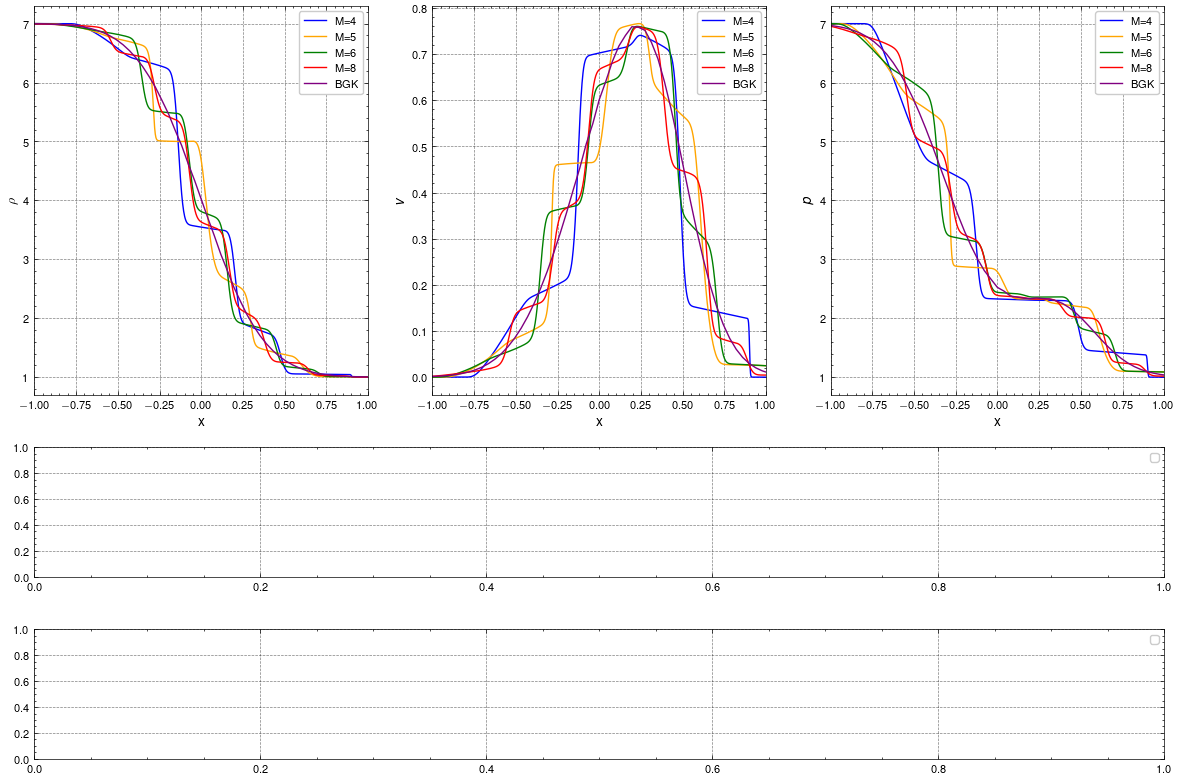

In [6]:
for closure in closure_vec:
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(3, 3, height_ratios=[3, 1, 1])
    
    ax_rho = fig.add_subplot(gs[0, 0])
    ax_v   = fig.add_subplot(gs[0, 1])
    ax_p   = fig.add_subplot(gs[0, 2])
    ax_eig_even = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    ax_eig_odd = fig.add_subplot(gs[2, :]) # Span all columns for the eigenvalue line
    
    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
    for i, M in enumerate(M_vector):
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        # df = pd.read_csv(file)
        # x_dest = 0.0
        # x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        # eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        # if M == 4:
        #     ax = ax_eig_even
        # elif M==5:
        #     ax = ax_eig_odd
        # else:
        #     continue
        # print(f"Plotting eigenvalues for M={M}, closure={closure}: {eigenvalues_at_x}")
        # ax.hlines(
        #     0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
        #     colors='black', linewidth=0.8, zorder=1
        # )
        # ax.scatter(
        #     eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
        #     marker='s', s=60, color=colors[i], zorder=2
        # )
        # ax.get_yaxis().set_visible(False)
        # for spine in ['left', 'right', 'top']:
        #     ax.spines[spine].set_visible(False)
        # ax.grid()
        # ax.get_yaxis().set_visible(False) # Hides ticks and label
        # ax.spines['left'].set_visible(False) # Hides the left vertical line
        # ax.spines['right'].set_visible(False)
        # ax.spines['top'].set_visible(False)
        # ax.set_xlabel('Index')
        # ax.set_ylabel('Value')
        # ax.set_title(f'Moments and Eigenvalues at M={M}')

    # BGK
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

    v_bgk = data_bgk['v'].to_numpy()
    ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')

    fig.tight_layout()
    fig.show()
    
    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()
    ax_eig_even.legend()
    ax_eig_odd.legend()

    fig.tight_layout()
    fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/2516976388.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_eig.legend()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/2516976388.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/2516976388.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_eig.legend()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_87475/2516976388.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


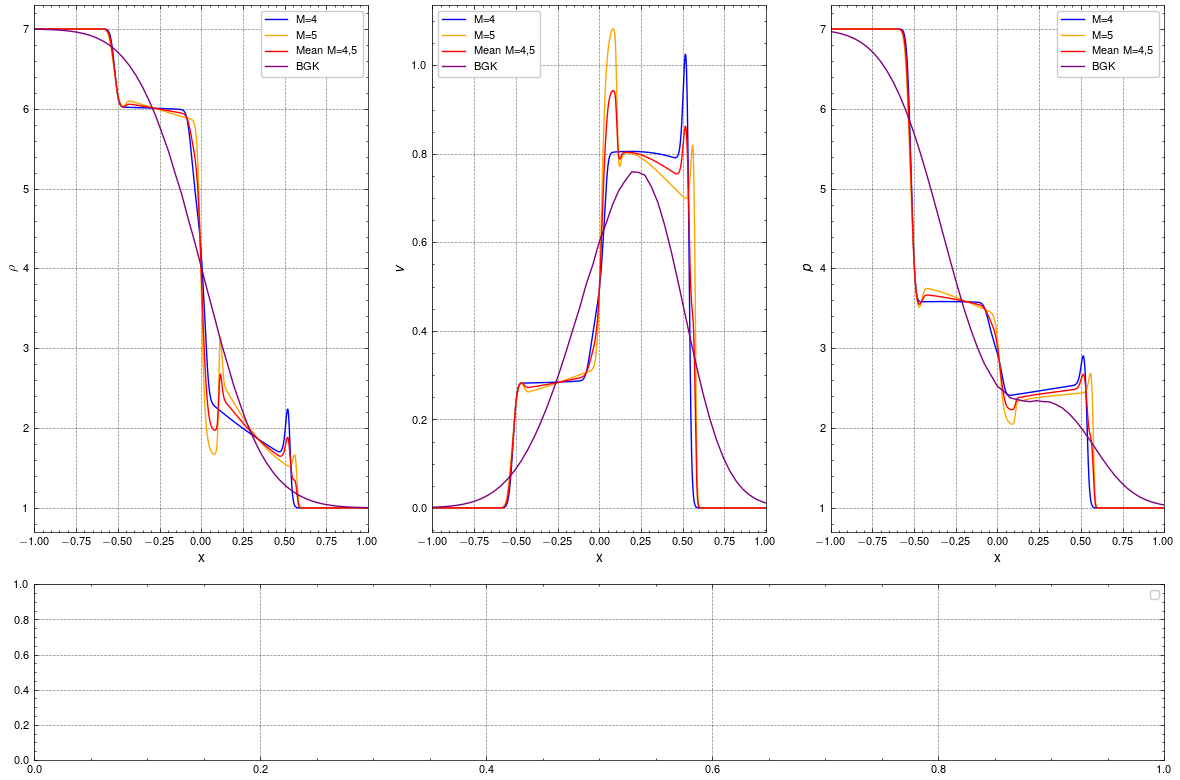

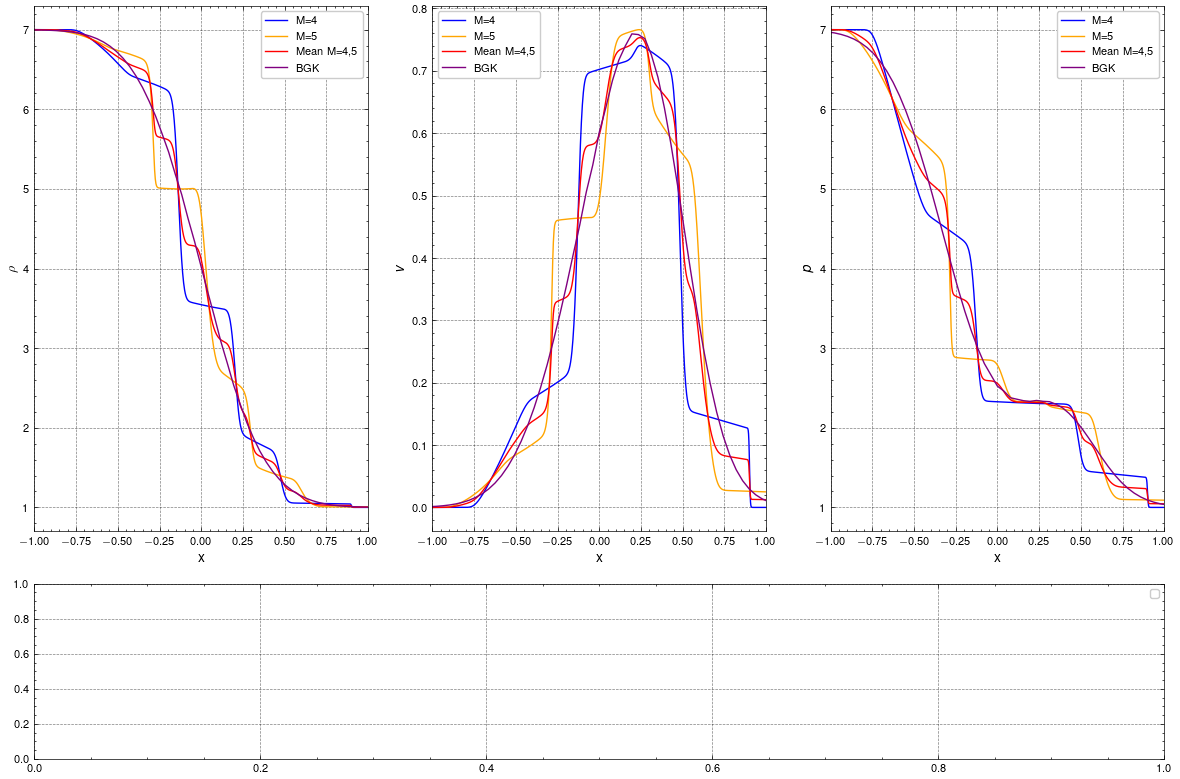

In [7]:
for closure in closure_vec:
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
    ax_rho = fig.add_subplot(gs[0, 0])
    ax_v   = fig.add_subplot(gs[0, 1])
    ax_p   = fig.add_subplot(gs[0, 2])
    ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

    rho_vector, v_vector, p_vector = [], [], []
    
    for i, M in enumerate([4, 5]):
        # Moments
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        rho_vector.append(rho)
        v = u[:, 1] / rho
        v_vector.append(v)
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        p_vector.append(p)
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # # Eigenvalues
        # file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        # df = pd.read_csv(file)
        # x_dest = 0.0
        # x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        # eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        # ax_eig.hlines(
        #     0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
        #     colors='black', linewidth=0.8, zorder=1
        # )
        # ax_eig.scatter(
        #     eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
        #     marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
        # )
        # ax_eig.get_yaxis().set_visible(False)
        # for spine in ['left', 'right', 'top']:
        #     ax_eig.spines[spine].set_visible(False)
        # ax_eig.grid()
        # ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
        # ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
        # ax_eig.spines['right'].set_visible(False)
        # ax_eig.spines['top'].set_visible(False)
        # ax_eig.set_xlabel('Index')
        # ax_eig.set_ylabel('Value')
        # ax_eig.set_title('Moments and Eigenvalues at x=0')

    # Mean of M=4 and M=5
    rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
    v_mean = 0.5 * (v_vector[0] + v_vector[1])
    p_mean = 0.5 * (p_vector[0] + p_vector[1])

    ax_rho.plot(x, rho_mean, color=colors[3], label='Mean M=4,5')
    ax_v.plot(x, v_mean, color=colors[3], label='Mean M=4,5')
    ax_p.plot(x, p_mean, color=colors[3], label='Mean M=4,5')

    # BGK
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

    v_bgk = data_bgk['v'].to_numpy()
    ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
    
    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()
    ax_eig.legend()

    fig.tight_layout()
    fig.show()

In [8]:
# for closure in closure_vec:
#     fig = plt.figure(figsize=(12, 8))
#     gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
#     ax_rho = fig.add_subplot(gs[0, 0])
#     ax_v   = fig.add_subplot(gs[0, 1])
#     ax_p   = fig.add_subplot(gs[0, 2])
#     ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
#     [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
#     [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
#     [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
#     for i, M in enumerate([7, 8]):
#         # Moments
#         file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

#         x, u, _ = sol_final(file)
#         rho = u[:, 0]
#         v = u[:, 1] / rho
#         p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
#         theta = p / rho

#         ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
#         ax_v.plot(x, v, color=colors[i], label=f'M={M}')
#         ax_p.plot(x, p, color=colors[i], label=f'M={M}')

#         # # Eigenvalues
#         # file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
#         # df = pd.read_csv(file)
#         # x_dest = 0.0
#         # x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
#         # eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

#         # ax_eig.hlines(
#         #     0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
#         #     colors='black', linewidth=0.8, zorder=1
#         # )
#         # ax_eig.scatter(
#         #     eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
#         #     marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
#         # )
#         # ax_eig.get_yaxis().set_visible(False)
#         # for spine in ['left', 'right', 'top']:
#         #     ax_eig.spines[spine].set_visible(False)
#         # ax_eig.grid()
#         # ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
#         # ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
#         # ax_eig.spines['right'].set_visible(False)
#         # ax_eig.spines['top'].set_visible(False)
#         # ax_eig.set_xlabel('Index')
#         # ax_eig.set_ylabel('Value')
#         # ax_eig.set_title('Moments and Eigenvalues at x=0')

#     # BGK
#     data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

#     x_bgk = data_bgk['x'].to_numpy()

#     rho_bgk = data_bgk['rho'].to_numpy()
#     ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

#     v_bgk = data_bgk['v'].to_numpy()
#     ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

#     p_bgk = data_bgk['p'].to_numpy()
#     theta_bgk = p_bgk / rho_bgk
#     ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
    
#     ax_rho.legend()
#     ax_v.legend()
#     ax_p.legend()
#     ax_eig.legend()

#     fig.tight_layout()
#     fig.show()

In [9]:
# file = '../out/Riemann1D/eigenvalues.csv'
# df = pd.read_csv(file)
# df.head()

In [10]:
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

In [11]:
# plt.subplots()
# plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label='Eigenvalues at x=0')
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.title('Moments and Eigenvalues at x=0')
# plt.legend()
# plt.show()

## Test-values for analytical

In [12]:
base_tree_level = 11
M = 4
closure = "Gram"

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx]
eigenvalue_string = df['eigenvalue'][0]
eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
eigenvalues_at_x, len(eigenvalues_at_x), type(eigenvalues_at_x)

([-1.7320508075688705,
  -1.0000000000000164,
  7.343512411761791e-18,
  1.000000000000016,
  1.7320508075688683],
 5,
 list)

-------------------------
Closure: Gram
Closure: Gram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208335e-16, 21.00000000000005]
Eigenvalues:  [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]


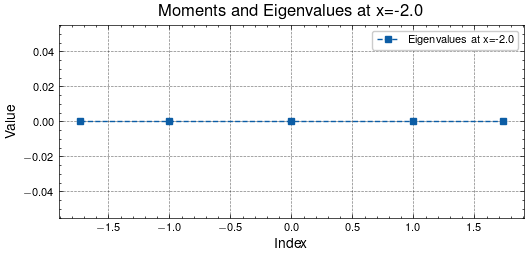

-------------------------
Closure: Gram
Moments:  [4.195602311592205, 2.067154917053888, 3.957688671939238, 5.024639471065429, 11.600939894040938]
Eigenvalues:  [-1.8132346401090111, -0.31448689961020876, 0.10735561117401621, 1.3605838265280976, 1.7058805649816562]


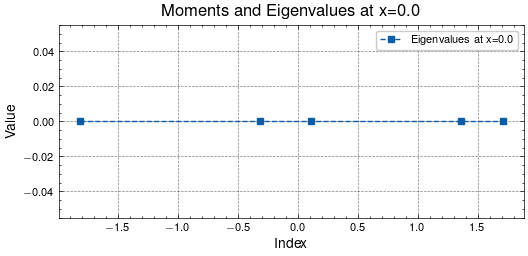

-------------------------
-------------------------
Closure: ExtGram
Closure: ExtGram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208173e-16, 21.00000000000005]
Eigenvalues:  [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]


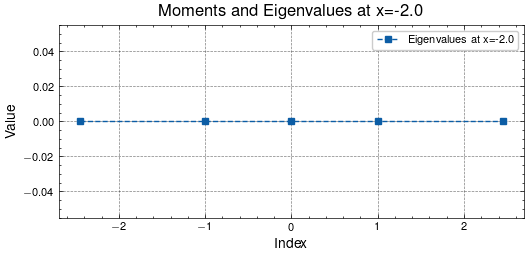

-------------------------
Closure: ExtGram
Moments:  [3.546083199088639, 2.490714226509468, 4.076038884772645, 4.763055972850697, 11.54943806535261]
Eigenvalues:  [-2.2527979684643764, -0.45337652822361657, 0.6713584498987106, 1.2700655127467608, 2.806473847126799]


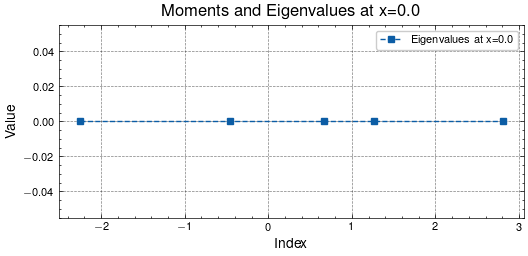

-------------------------
-------------------------
Closure: Gram


AttributeError: 'numpy.float64' object has no attribute 'strip'

In [13]:
for M in M_vector:
    for closure in closure_vec:
        print("-------------------------")
        print(f'Closure: {closure}')
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)

        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)


        x_dest = -2.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

# Analytical

### M = 4

In [14]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [15]:
M = 4
n = int(M/2)

## Gramian

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(c^{3} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{2}}


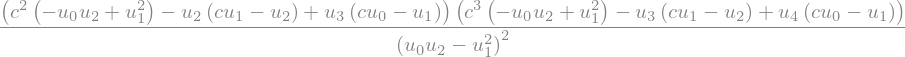

In [20]:
P = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42
)
P = simplify(P(c))

print(f'Latex expression of characteristic polynomial: {latex(P)}')
P

In [22]:
#! We don't want to use this, it seems to add imaginary parts due to numerical errors

# # Roots of P give the eigenvalues of DF
# roots = solve(Eq(P, 0), c)
# roots = [simplify(root) for root in roots]
# print(f'Latex expression of roots: {latex(roots)}')
# roots

In [23]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "Gram"
M = 4
base_tree_level = 11
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [24]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_subs = P.subs(subs_dict_equilibrium)
P_subs = simplify(P_subs)

roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-1.73205080756888, -1.00000000000000, 0.0, 1.00000000000000, 1.73205080756888]
Sorted Computed Eigenvalues: [-1.73205080756888, -1.00000000000000, 0, 1.00000000000000, 1.73205080756888]
Sorted Test Eigenvalues: [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]
Relative Errors: [3.84592537276714e-15, 1.64313007644520e-14, 1.00000000000000, 1.59872115546020e-14, 5.12790049702286e-15]
Absolute Errors: [6.66133814775094e-15, 1.64313007644523e-14, 7.34351241176179e-18, 1.59872115546023e-14, 8.88178419700125e-15]


In [27]:
# Get numerical eigenvalues at x=0.0 (equilibrium)

closure = "Gram"
M = 4
base_tree_level = 11
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [28]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_subs = P.subs(subs_dict)
P_subs = simplify(P_subs)

roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.81323478926610, -0.314486965091687, 0.107355572066247, 1.36058542717294, 1.70587921719986]
Sorted Test Eigenvalues: [-1.8132346401090111, -0.31448689961020876, 0.10735561117401621, 1.3605838265280976, 1.7058805649816562]
Relative Errors: [8.22602261546544e-8, 2.08216870926433e-7, 3.64282491701791e-7, 1.17643970928419e-6, 7.90079814267352e-7]
Absolute Errors: [1.49157091566821e-7, 6.54814781841928e-8, 3.91077695366393e-8, 1.60064484133748e-6, 1.34778179994299e-6]


## Extended Gramian

In [29]:
chi = (n+1) / n

In [30]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(- c^{3} \left(u_{0} u_{2} - u_{1}^{2}\right)^{2} - 1.5 \left(c u_{0} - u_{1}\right) \left(u_{2} \left(- u_{1} u_{3} + u_{2}^{2}\right) + u_{3} \left(u_{0} u_{3} - u_{1} u_{2}\right) - u_{4} \left(u_{0} u_{2} - u_{1}^{2}\right)\right) + \left(u_{0} u_{2} - u_{1}^{2}\right) \left(- u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{3}}


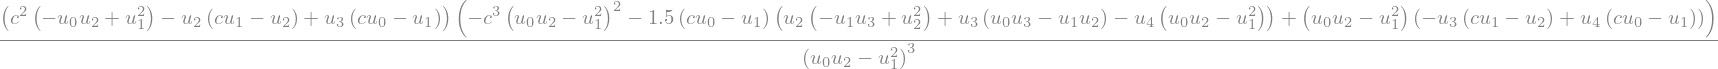

In [31]:
P = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P = simplify(P(c))

print(f'Latex expression of characteristic polynomial: {latex(P)}')
P

In [32]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "ExtGram"
M = 4
base_tree_level = 11
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [33]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_subs = P.subs(subs_dict_equilibrium)
P_subs = simplify(P_subs)

roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-2.44948974278318, -1.00000000000000, 0.0, 1.00000000000000, 2.44948974278318]
Sorted Computed Eigenvalues: [-2.44948974278318, -1.00000000000000, 0, 1.00000000000000, 2.44948974278318]
Sorted Test Eigenvalues: [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]
Relative Errors: [5.25766116130737e-15, 1.31006316905767e-14, 1.00000000000000, 1.37667655053518e-14, 4.89506383983789e-15]
Absolute Errors: [1.28785870856518e-14, 1.31006316905768e-14, 7.78350085366586e-18, 1.37667655053519e-14, 1.19904086659517e-14]


In [35]:
# Get numerical eigenvalues at x=0.0
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [36]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_subs = P.subs(subs_dict)
P_subs = simplify(P_subs)
print(P_subs)

roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

-0.0017806899442362*(-8.25031564998761*c**2 + 6.73794472353564*c + 4.7506817169385)*(68.0677083244305*c**3 - 473.150723703772*c + 240.906060618896)
[-0.453376603407698, 1.27006592893014, -2.86147292415205 + 0.e-22*I, 0.530649219222094 - 0.e-22*I, 2.33082370492996 + 0.e-22*I]
Sorted Computed Eigenvalues: [-2.86147292415205, -0.453376603407698, 0.530649219222094, 1.27006592893014, 2.33082370492996]
Sorted Test Eigenvalues: [-2.2527979684643764, -0.45337652822361657, 0.6713584498987106, 1.2700655127467608, 2.806473847126799]
Relative Errors: [0.270186214746359, 1.65831438604102e-7, 0.209588827991731, 3.27686546020053e-7, 0.169483190689198]
Absolute Errors: [0.608674955687678, 7.51840819046556e-8, 0.140709230676616, 4.16183381091173e-7, 0.475650142196839]
